In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("dirty_ecommerce_dataset.csv")

In [5]:
df.head()

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount
0,ORD10001,CUST1001,Customer_1,NaN,01-01-2025,Sports,5,11202.0,15,Net Banking,Returned,1.0,6.0,47608.5
1,ORD10002,CUST1002,Customer_2,Ghaziabad,01-01-2025,Electronics,3,9718.0,20,Cash on Delivery,Shipped,4.0,6.0,23323.2
2,ORD10003,CUST1003,Customer_3,Faridabad,02-01-2025,Electronics,5,13458.0,0,Net Banking,Delivered,4.0,5.0,67290.0
3,ORD10004,CUST1004,Customer_4,Lucknow,02-01-2025,Electronics,2,1219.0,0,Debit Card,Returned,2.0,3.0,2438.0
4,ORD10005,CUST1005,Customer_5,Gurgaon,03-01-2025,Grocery,1,5437.0,0,Cash on Delivery,Delivered,2.0,6.0,5437.0


In [6]:
df.shape

(1010, 14)

In [7]:
df.isnull().sum()

Order_ID             0
Customer_ID          0
Customer_Name        0
City                30
Order_Date           0
Product_Category     0
Quantity             0
Unit_Price          21
Discount             0
Payment_Method      25
Order_Status         0
Customer_Rating     51
Delivery_Days       32
Total_Amount         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(8)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(1002, 14)

In [13]:
df["City"] = df["City"].fillna("Unknown")

In [15]:
df["Unit_Price"].dtype

<StringDtype(na_value=nan)>

In [17]:
df["Unit_Price"] = df["Unit_Price"].astype(str).str.replace(r"[^0-9.-]", "", regex=True)
df["Unit_Price"] = df["Unit_Price"].replace("", np.nan)
df["Unit_Price"] = df["Unit_Price"].astype(float)
df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())

In [19]:
df["Unit_Price"].isnull().sum()

np.int64(0)

In [21]:
df["Payment_Method"] = df["Payment_Method"].fillna("unknown")

In [22]:
df["Payment_Method"].isnull().sum()

np.int64(0)

In [23]:
df["Customer_Rating"] = df["Customer_Rating"].fillna(df["Customer_Rating"].median())

In [24]:
df["Customer_Rating"].isnull().sum()

np.int64(0)

In [26]:
df["Delivery_Days"] = df["Delivery_Days"].fillna(df["Delivery_Days"].median())

In [27]:
df["Delivery_Days"].isnull().sum()

np.int64(0)

In [28]:
df.isnull().sum()

Order_ID            0
Customer_ID         0
Customer_Name       0
City                0
Order_Date          0
Product_Category    0
Quantity            0
Unit_Price          0
Discount            0
Payment_Method      0
Order_Status        0
Customer_Rating     0
Delivery_Days       0
Total_Amount        0
dtype: int64

In [29]:
df.dtypes

Order_ID                str
Customer_ID             str
Customer_Name           str
City                    str
Order_Date              str
Product_Category        str
Quantity              int64
Unit_Price          float64
Discount              int64
Payment_Method          str
Order_Status            str
Customer_Rating     float64
Delivery_Days       float64
Total_Amount        float64
dtype: object

In [30]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"],errors="coerce")

In [31]:
df.dtypes

Order_ID                       str
Customer_ID                    str
Customer_Name                  str
City                           str
Order_Date          datetime64[us]
Product_Category               str
Quantity                     int64
Unit_Price                 float64
Discount                     int64
Payment_Method                 str
Order_Status                   str
Customer_Rating            float64
Delivery_Days              float64
Total_Amount               float64
dtype: object

In [32]:
df.describe()

,Order_Date,Quantity,Unit_Price,Discount,Customer_Rating,Delivery_Days,Total_Amount
count,397,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,2025-10-05 04:46:32.947103,3.047904,7536.548902,12.090818,2.963074,4.372255,20425.230639
min,2025-01-01 00:00:00,-2.000000,-500.000000,0.000000,0.000000,-3.000000,331.200000
25%,2025-05-04 00:00:00,2.000000,3753.000000,5.000000,2.000000,2.000000,6916.350000
50%,2025-09-06 00:00:00,3.000000,7383.000000,10.000000,3.000000,4.000000,15986.500000
75%,2026-02-04 00:00:00,4.000000,11299.000000,20.000000,4.000000,6.000000,31194.225000
max,2026-12-05 00:00:00,5.000000,14970.000000,25.000000,7.000000,8.000000,70860.500000
std,NaN,1.429565,4319.601086,8.580275,1.395595,2.267820,16282.450609


In [33]:
df[df["Quantity"] < 0]

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount
21,ORD10022,CUST1022,Customer_22,Faridabad,2025-11-01,Clothing,-2,13089.0,5,Cash on Delivery,Shipped,5.0,2.0,12434.55


In [34]:
df[df["Unit_Price"] < 0]

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount
25,ORD10026,CUST1026,Customer_26,Jaipur,NaT,Electronics,3,-500.0,15,Net Banking,Returned,5.0,7.0,22672.05


In [35]:
df[df["Delivery_Days"] < 0]

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount
24,ORD10025,CUST1025,Customer_25,Ghaziabad,NaT,Grocery,5,5824.0,20,Cash on Delivery,Delivered,5.0,-3.0,23296.0


In [39]:
df = df[
    (df["Quantity"] >= 0) &
    (df["Unit_Price"] >= 0) &
    (df["Delivery_Days"] >= 0)
]

In [40]:
df.shape

(999, 14)

In [41]:
df.isnull().sum()

Order_ID              0
Customer_ID           0
Customer_Name         0
City                  0
Order_Date          603
Product_Category      0
Quantity              0
Unit_Price            0
Discount              0
Payment_Method        0
Order_Status          0
Customer_Rating       0
Delivery_Days         0
Total_Amount          0
dtype: int64

In [44]:
df["Order_Date"] = df["Order_Date"].fillna(df["Order_Date"].mode()[0])

In [45]:
df["Order_Date"].isnull().sum()

np.int64(0)

In [46]:
df.isnull().sum()

Order_ID            0
Customer_ID         0
Customer_Name       0
City                0
Order_Date          0
Product_Category    0
Quantity            0
Unit_Price          0
Discount            0
Payment_Method      0
Order_Status        0
Customer_Rating     0
Delivery_Days       0
Total_Amount        0
dtype: int64

In [47]:
df.describe()

,Order_Date,Quantity,Unit_Price,Discount,Customer_Rating,Delivery_Days,Total_Amount
count,999,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,2025-08-31 15:31:10.270270,3.051051,7540.749750,12.087087,2.956957,4.379379,20428.106607
min,2025-01-01 00:00:00,0.000000,206.000000,0.000000,0.000000,1.000000,331.200000
25%,2025-08-09 00:00:00,2.000000,3770.000000,5.000000,2.000000,2.000000,6899.650000
50%,2025-08-09 00:00:00,3.000000,7383.000000,10.000000,3.000000,4.000000,15945.000000
75%,2025-08-09 00:00:00,4.000000,11297.000000,20.000000,4.000000,6.000000,31214.950000
max,2026-12-05 00:00:00,5.000000,14970.000000,25.000000,7.000000,8.000000,70860.500000
std,NaN,1.421421,4314.681816,8.586086,1.393209,2.256413,16304.534429


<Axes: >

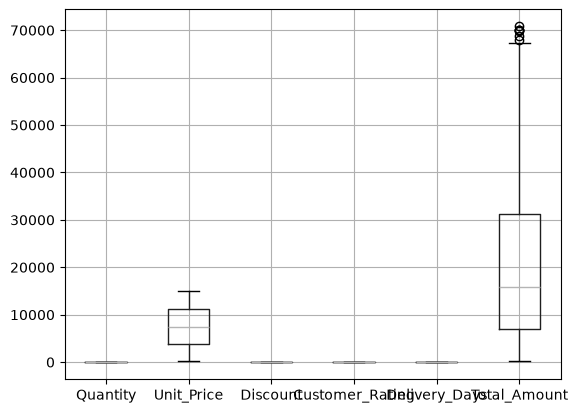

In [48]:
df[["Quantity", "Unit_Price", "Discount", "Customer_Rating", "Delivery_Days", "Total_Amount"]].boxplot()

In [49]:
Q1 = df["Unit_Price"].quantile(0.25)
Q3 = df["Unit_Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[(df["Unit_Price"] < lower) | (df["Unit_Price"] > upper)]

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount


In [50]:
Q1 = df["Total_Amount"].quantile(0.25)
Q3 = df["Total_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[(df["Total_Amount"] < lower) | (df["Total_Amount"] > upper)]

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount
208,ORD10209,CUST1209,Customer_209,Jaipur,2025-08-09,Sports,5,7383.0,5,Debit Card,Delivered,3.0,4.0,70860.50
216,ORD10217,CUST1217,Customer_217,Ghaziabad,2025-08-09,Electronics,5,14748.0,5,Credit Card,Delivered,2.0,3.0,70053.00
347,ORD10348,CUST1348,Customer_348,Ghaziabad,2025-08-09,Grocery,5,13737.0,0,Credit Card,Cancelled,5.0,6.0,68685.00
559,ORD10560,CUST1210,Customer_210,Jaipur,2025-07-10,Sports,5,14767.0,5,Debit Card,Delivered,4.0,3.0,70143.25
575,ORD10576,CUST1226,Customer_226,Jaipur,2025-08-09,Electronics,5,14003.0,0,Net Banking,Shipped,4.0,8.0,70015.00
695,ORD10696,CUST1346,Customer_346,Ghaziabad,2025-08-09,Clothing,5,13595.0,0,Cash on Delivery,Cancelled,3.0,1.0,67975.00
756,ORD10757,CUST1057,Customer_57,Noida,2025-08-09,Home & Kitchen,5,13949.0,0,unknown,Delivered,2.0,6.0,69745.00


In [51]:
df[df["Total_Amount"] > upper][["Order_ID", "Quantity", "Unit_Price", "Discount", "Total_Amount"]]

,Order_ID,Quantity,Unit_Price,Discount,Total_Amount
208,ORD10209,5,7383.0,5,70860.50
216,ORD10217,5,14748.0,5,70053.00
347,ORD10348,5,13737.0,0,68685.00
559,ORD10560,5,14767.0,5,70143.25
575,ORD10576,5,14003.0,0,70015.00
695,ORD10696,5,13595.0,0,67975.00
756,ORD10757,5,13949.0,0,69745.00


In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.shape

(999, 14)

In [54]:
df.info()

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 1009
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          999 non-null    str           
 1   Customer_ID       999 non-null    str           
 2   Customer_Name     999 non-null    str           
 3   City              999 non-null    str           
 4   Order_Date        999 non-null    datetime64[us]
 5   Product_Category  999 non-null    str           
 6   Quantity          999 non-null    int64         
 7   Unit_Price        999 non-null    float64       
 8   Discount          999 non-null    int64         
 9   Payment_Method    999 non-null    str           
 10  Order_Status      999 non-null    str           
 11  Customer_Rating   999 non-null    float64       
 12  Delivery_Days     999 non-null    float64       
 13  Total_Amount      999 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(2

In [55]:
df.head()

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount
0,ORD10001,CUST1001,Customer_1,Unknown,2025-01-01,Sports,5,11202.0,15,Net Banking,Returned,1.0,6.0,47608.5
1,ORD10002,CUST1002,Customer_2,Ghaziabad,2025-01-01,Electronics,3,9718.0,20,Cash on Delivery,Shipped,4.0,6.0,23323.2
2,ORD10003,CUST1003,Customer_3,Faridabad,2025-02-01,Electronics,5,13458.0,0,Net Banking,Delivered,4.0,5.0,67290.0
3,ORD10004,CUST1004,Customer_4,Lucknow,2025-02-01,Electronics,2,1219.0,0,Debit Card,Returned,2.0,3.0,2438.0
4,ORD10005,CUST1005,Customer_5,Gurgaon,2025-03-01,Grocery,1,5437.0,0,Cash on Delivery,Delivered,2.0,6.0,5437.0


In [56]:
df.shape

(999, 14)

In [57]:
df.isnull().sum().sum()

np.int64(0)

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.to_csv("Cleaned_Online_Sales_Data.csv", index=False)

In [60]:
df.head()

,Order_ID,Customer_ID,Customer_Name,City,Order_Date,Product_Category,Quantity,Unit_Price,Discount,Payment_Method,Order_Status,Customer_Rating,Delivery_Days,Total_Amount
0,ORD10001,CUST1001,Customer_1,Unknown,2025-01-01,Sports,5,11202.0,15,Net Banking,Returned,1.0,6.0,47608.5
1,ORD10002,CUST1002,Customer_2,Ghaziabad,2025-01-01,Electronics,3,9718.0,20,Cash on Delivery,Shipped,4.0,6.0,23323.2
2,ORD10003,CUST1003,Customer_3,Faridabad,2025-02-01,Electronics,5,13458.0,0,Net Banking,Delivered,4.0,5.0,67290.0
3,ORD10004,CUST1004,Customer_4,Lucknow,2025-02-01,Electronics,2,1219.0,0,Debit Card,Returned,2.0,3.0,2438.0
4,ORD10005,CUST1005,Customer_5,Gurgaon,2025-03-01,Grocery,1,5437.0,0,Cash on Delivery,Delivered,2.0,6.0,5437.0
